# Principal Component Analysis (PCA)

In this notebook, I will be applying PCA to a Heart Disease dataset containing 13 clinical features.



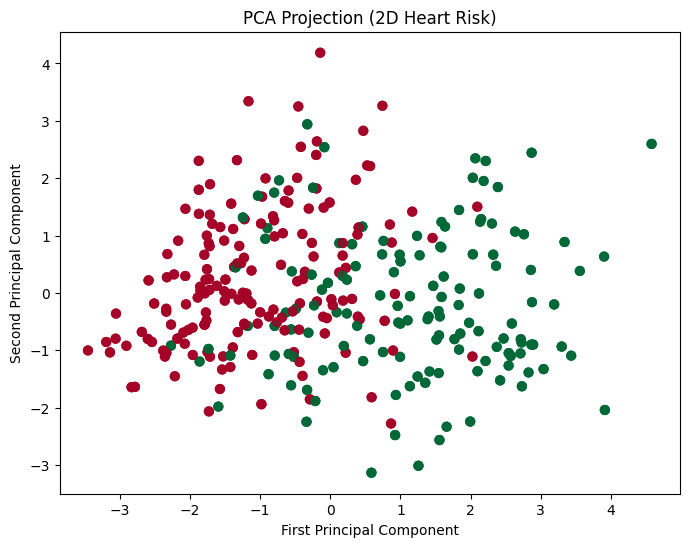

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv("heart.csv")

# Preprocessing: 'target' 1 = disease, 0 = no disease
X = df.drop('target', axis=1)
y = df['target']

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA: reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='RdYlGn_r', s=40, alpha=0.7)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA Projection (2D Heart Risk)")
plt.show()

# Analysis of results:

The First Principal Component combines multiple clinical features (like age, cholesterol, and heart rate) into a single value that best captures the differences across patients.

The Second Principal Component is the second-best combination of these features, showing additional variation not captured by PC1.

PC1 and PC2 form a 2D coordinate system that preserves as much of the original structure as possible. Each point on the plot represents a patient, positioned by how they score on these two new, combined dimensions.

pca.explained_variance_ratio_ = [0.21369912 0.11971959]
per_var = [21.37 11.97] 



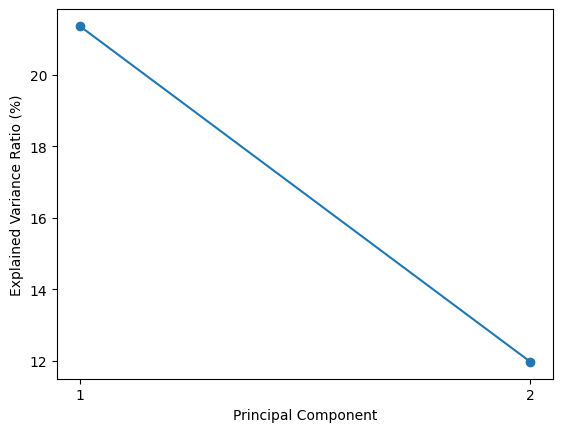

In [2]:
# Proportion of total variance explained by each component
print(f"pca.explained_variance_ratio_ = {pca.explained_variance_ratio_}")

each_var = np.round(pca.explained_variance_ratio_ * 100, 2)
print(f"per_var = {each_var} \n")

plt.plot(range(1,3), each_var, marker='o')
plt.xlabel('Principal Component')
plt.ylabel("Explained Variance Ratio (%)")
plt.xticks([1, 2])
plt.show()

We can analyze how well the data is captured by our Principal Components

# Conclusion

The first two principal components explain the majority of the variance in the heart health dataset. This shows that the 2D PCA plot captures the bulk of the original data's structure, making it highly useful for visualization. (PC1 -> 21.37% and PC2 -> 11.97)

It is important to note that because only the first two components were used, some percentage of the total variance was not visualized. Some class-separating information could be lost in this projection. Since PCA captures linear relationships, it might miss complex, nonlinear interactions between variables that a more complex model might find.

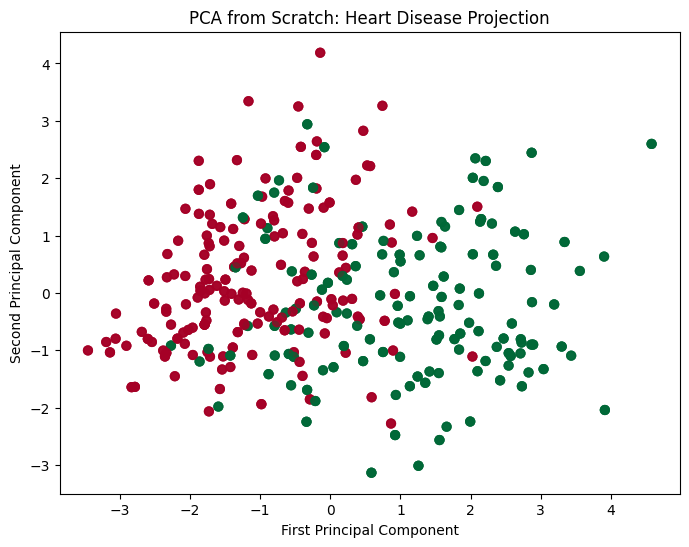

Explained Variance Ratio: [0.21369912 0.11971959]


In [3]:
# 1. Load and Clean Data
df = pd.read_csv("heart.csv")
X = df.drop('target', axis=1).values
y = df['target'].values

# 2. Standardize (Manual or using StandardScaler)
# We still need to scale so features like 'chol' don't overpower 'age'
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. If I wanted to try from scratch
# We initialize your custom PCA class for 2 components
custom_pca = PCA(n_components=2)

# 4. Fit and Transform
X_pca = custom_pca.fit_transform(X_scaled)

# 5. Visualization (Same as before)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='RdYlGn_r', s=40, alpha=0.7)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA from Scratch: Heart Disease Projection")
plt.show()

# 6. Check the Variance Explained
print(f"Explained Variance Ratio: {custom_pca.explained_variance_ratio_}")